# Notebook 05 — US Retail Gasoline Prices: Nominal vs Inflation-Adjusted

## Goal
Compare US retail gasoline prices over 30 years in two ways:
- **Nominal prices** — the actual dollar amount paid at the pump each week
- **Inflation-adjusted prices** — what those prices equal in today's dollars

Showing both side by side reveals whether gas is actually more expensive 
now than it was in 2008 or 2012, once you account for the changing value 
of money over time.

## Data Sources
- EIA Weekly US Retail Gasoline Prices (Regular Grade, All Formulations)
- FRED Monthly CPI (CPIAUCSL) — US Consumer Price Index, All Urban Consumers

## Outputs
- outputs/us_gas_prices.csv — cleaned and merged dataset with both price series
- outputs/us_gas_nominal_chart.png — nominal price chart
- outputs/us_gas_adjusted_chart.png — inflation-adjusted chart
- outputs/us_gas_comparison_chart.png — side by side comparison

## Loading the Data

Two files feed this notebook. The EIA gasoline file is weekly, with one 
price reading per Monday. The FRED CPI file is monthly. We load both, 
clean the date columns, and sort chronologically before doing anything else.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load gasoline prices (weekly, regular grade)
gas = pd.read_csv('../data/Weekly_U.S._Regular_All_Formulations_Retail_Gasoline_Prices.csv',
                  skiprows=5, names=['date', 'gas_price'])
gas['date'] = pd.to_datetime(gas['date'], format='%m/%d/%Y', errors='coerce')
gas = gas.dropna().sort_values('date').reset_index(drop=True)

# Load CPI data (monthly from FRED)
cpi = pd.read_csv('../data/BLS_CPI_monthly.csv', parse_dates=['observation_date'])
cpi = cpi.rename(columns={'observation_date': 'date', 'CPIAUCSL': 'cpi'})
cpi = cpi.sort_values('date').reset_index(drop=True)

print(gas.tail())
print(cpi.tail())

           date  gas_price
1846 2026-02-16      2.924
1847 2026-02-23      2.937
1848 2026-03-02      3.015
1849 2026-03-09      3.502
1850 2026-03-16      3.720
          date      cpi
393 2025-10-01      NaN
394 2025-11-01  325.063
395 2025-12-01  326.031
396 2026-01-01  326.588
397 2026-02-01  327.460


## Adjusting for Inflation

Gas prices are reported in nominal dollars — the actual price paid at the 
pump that week. But a dollar in 1993 bought a lot more than a dollar today, 
which makes direct comparisons misleading.

To fix this we adjust all historical prices into today's dollars using the 
Consumer Price Index (CPI). The formula is simple:

**Adjusted Price = Nominal Price x (Latest CPI / CPI at time of purchase)**

This tells us what each week's gas price would cost in February 2026 dollars, 
making the full 30 year history directly comparable.

- CPI data is monthly so we match each weekly gas price to its corresponding month
- March 2026 CPI is not yet published, so we carry forward February 2026 as a proxy

In [2]:
# Forward fill the NaN CPI value explicitly
cpi['cpi'] = cpi['cpi'].fillna(cpi['cpi'].bfill())

# Add month columns for merging
gas['month'] = gas['date'].dt.to_period('M')
cpi['month'] = cpi['date'].dt.to_period('M')

# Merge CPI into gas on month
gas = gas.merge(cpi[['month', 'cpi']], on='month', how='left')

# Force cpi column to numeric just in case
gas['cpi'] = pd.to_numeric(gas['cpi'], errors='coerce')

# Get the latest CPI value as a plain float
cpi_latest = float(cpi['cpi'].dropna().iloc[-1])
print(f"Latest CPI value: {cpi_latest}")
print(f"Type: {type(cpi_latest)}")

# Calculate inflation-adjusted price in today's dollars
gas['gas_price_adjusted'] = gas['gas_price'] * (cpi_latest / gas['cpi'])

print(gas.tail(10))

Latest CPI value: 327.46
Type: <class 'float'>
           date  gas_price    month      cpi  gas_price_adjusted
1841 2026-01-12      2.779  2026-01  326.588            2.786420
1842 2026-01-19      2.806  2026-01  326.588            2.813492
1843 2026-01-26      2.853  2026-01  326.588            2.860618
1844 2026-02-02      2.867  2026-02  327.460            2.867000
1845 2026-02-09      2.902  2026-02  327.460            2.902000
1846 2026-02-16      2.924  2026-02  327.460            2.924000
1847 2026-02-23      2.937  2026-02  327.460            2.937000
1848 2026-03-02      3.015  2026-03      NaN                 NaN
1849 2026-03-09      3.502  2026-03      NaN                 NaN
1850 2026-03-16      3.720  2026-03      NaN                 NaN


In [3]:
# Forward fill missing CPI for months not yet published (e.g. March 2026)
gas['cpi'] = gas['cpi'].ffill()

# Recalculate adjusted price now that CPI is filled
gas['gas_price_adjusted'] = gas['gas_price'] * (cpi_latest / gas['cpi'])

print(gas.tail(10))

           date  gas_price    month      cpi  gas_price_adjusted
1841 2026-01-12      2.779  2026-01  326.588            2.786420
1842 2026-01-19      2.806  2026-01  326.588            2.813492
1843 2026-01-26      2.853  2026-01  326.588            2.860618
1844 2026-02-02      2.867  2026-02  327.460            2.867000
1845 2026-02-09      2.902  2026-02  327.460            2.902000
1846 2026-02-16      2.924  2026-02  327.460            2.924000
1847 2026-02-23      2.937  2026-02  327.460            2.937000
1848 2026-03-02      3.015  2026-03  327.460            3.015000
1849 2026-03-09      3.502  2026-03  327.460            3.502000
1850 2026-03-16      3.720  2026-03  327.460            3.720000


## Saving the Cleaned Dataset

Filter to 1993 onward to match the rest of the project, then save to outputs.

In [4]:
# Filter to 1993 onward to match the rest of the project
gas = gas[gas['date'] >= '1993-01-01'].reset_index(drop=True)

# Save to outputs
gas.to_csv('../outputs/us_gas_prices.csv', index=False)
print(f"Saved {len(gas)} rows to us_gas_prices.csv")
print(gas.head(3))

Saved 1733 rows to us_gas_prices.csv
        date  gas_price    month    cpi  gas_price_adjusted
0 1993-01-04      1.065  1993-01  142.8            2.442191
1 1993-01-11      1.066  1993-01  142.8            2.444484
2 1993-01-18      1.061  1993-01  142.8            2.433019


## Nominal vs Inflation-Adjusted: Side by Side

Two charts using the same y-axis scale so the difference is immediately 
visible. The left shows what people actually paid. The right shows what 
that cost in real terms.

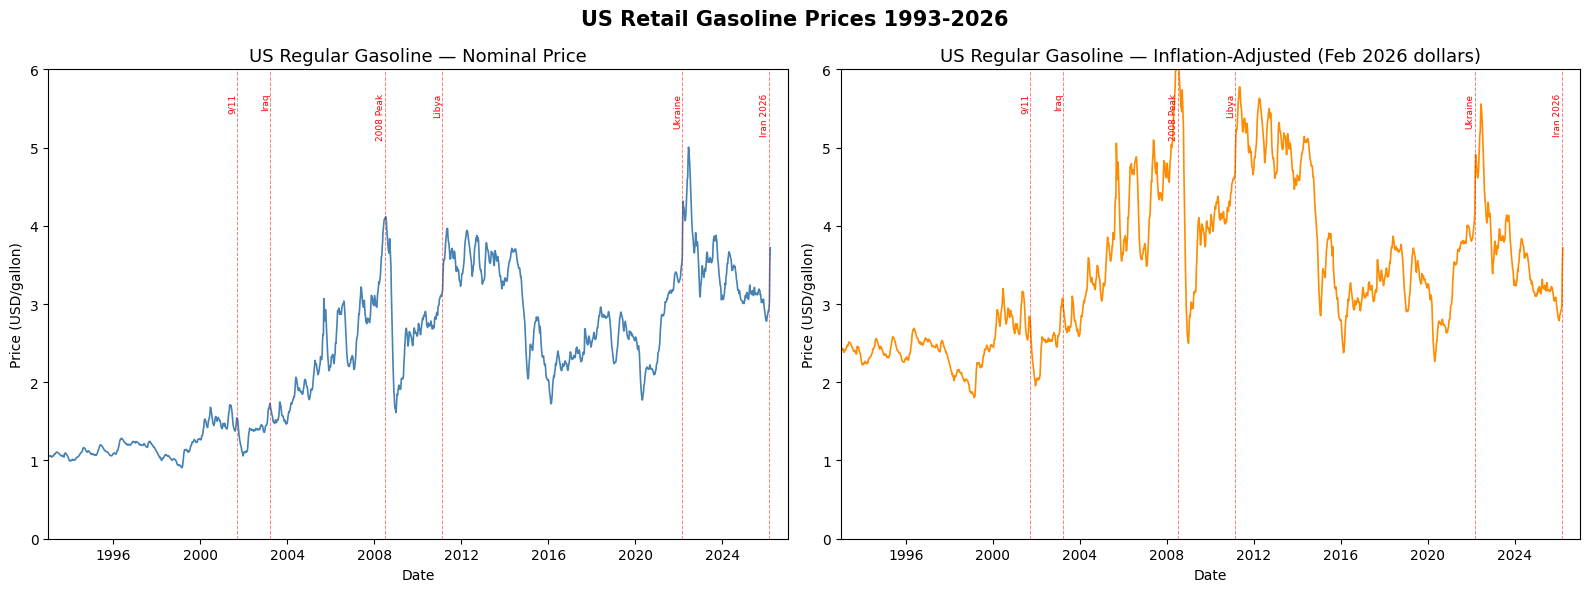

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=False)

# ── Left chart: Nominal prices ──
ax1.plot(gas['date'], gas['gas_price'], color='steelblue', linewidth=1.2)
ax1.set_title('US Regular Gasoline — Nominal Price', fontsize=13)
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD/gallon)')
ax1.set_ylim(0, 6)

# ── Right chart: Inflation-adjusted prices ──
ax2.plot(gas['date'], gas['gas_price_adjusted'], color='darkorange', linewidth=1.2)
ax2.set_title('US Regular Gasoline — Inflation-Adjusted (Feb 2026 dollars)', fontsize=13)
ax2.set_xlabel('Date')
ax2.set_ylabel('Price (USD/gallon)')
ax2.set_ylim(0, 6)
ax1.set_xlim(pd.Timestamp('1993-01-01'), pd.Timestamp('2026-12-31'))
ax2.set_xlim(pd.Timestamp('1993-01-01'), pd.Timestamp('2026-12-31'))

# ── Add key event lines to both charts ──
events = [
    ('2001-09-11', '9/11'),
    ('2003-03-20', 'Iraq'),
    ('2008-07-03', '2008 Peak'),
    ('2011-02-17', 'Libya'),
    ('2022-02-24', 'Ukraine'),
    ('2026-03-02', 'Iran 2026'),
]

for ax in [ax1, ax2]:
    for date, label in events:
        ax.axvline(pd.Timestamp(date), color='red', linewidth=0.7, linestyle='--', alpha=0.5)
        ax.text(pd.Timestamp(date), 5.7, label, fontsize=6.5, color='red',
                rotation=90, ha='right', va='top')

plt.suptitle('US Retail Gasoline Prices 1993-2026', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/us_gas_comparison_chart.png', dpi=150)
plt.show()

## What the Charts Show

The two charts tell meaningfully different stories depending on which one you look at.

**The nominal chart** makes today's prices look historically high. The Iran 2026 
spike is dramatic and the overall trend since the 1990s looks like a steady climb.

**The inflation-adjusted chart** reframes everything:
- Gas in the early 1990s wasn't as cheap as it looks. $1.06 in 1993 equals 
  about $2.44 in today's dollars
- The 2008 peak is the true historical high in real terms, reaching nearly $5.00 
  per gallon in February 2026 dollars
- The Iran 2026 spike is significant but has not yet approached 2008 levels
- The period from 2014 to 2020 was genuinely cheap gas in real terms, 
  not just nominally

**Key takeaway:** When people say gas prices are at historic highs, the data 
says otherwise. In real dollars, 2008 was worse.

## US Gas Prices vs Brent Crude

Brent crude is the global benchmark for oil pricing. Gasoline is refined from 
crude oil, so when Brent moves, pump prices generally follow — but with a lag 
and some dampening. This chart overlays the two to show how tightly connected 
they are and where they diverge.

Note: Brent is priced per barrel, gas per gallon. We plot them on separate 
y-axes so the shapes are comparable without the scale difference distorting 
the relationship.

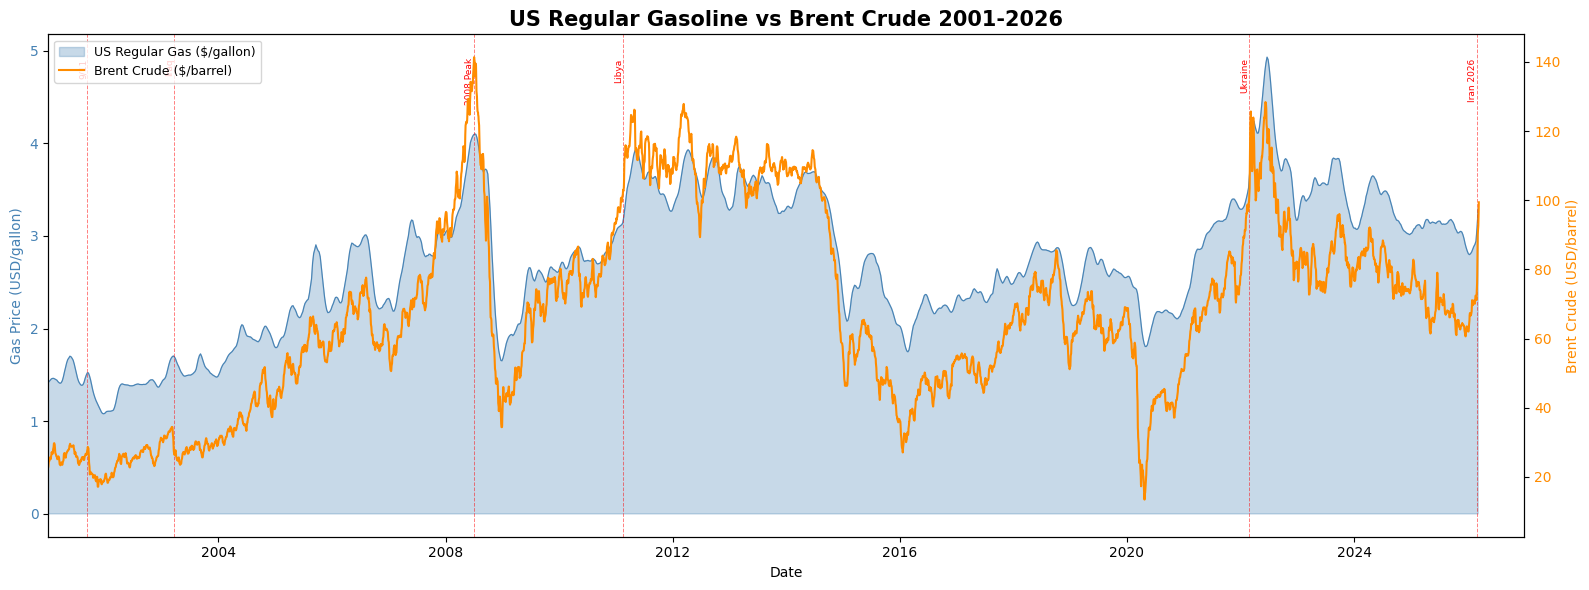

In [12]:
fig, ax1 = plt.subplots(figsize=(16, 6))

# ── Smooth both series with a 4-week rolling average ──
gas_smooth = gas['gas_price'].rolling(window=4, center=True).mean()
brent_smooth = master['brent'].rolling(window=4, center=True).mean()

# ── Left y-axis: Gas price as filled area ──
ax1.fill_between(gas['date'], gas_smooth, alpha=0.3, color='steelblue', label='US Regular Gas ($/gallon)')
ax1.plot(gas['date'], gas_smooth, color='steelblue', linewidth=0.8)
ax1.set_xlabel('Date')
ax1.set_ylabel('Gas Price (USD/gallon)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlim(pd.Timestamp('2001-01-01'), pd.Timestamp('2026-12-31'))

# ── Right y-axis: Brent crude as line ──
ax2 = ax1.twinx()
ax2.plot(master['date'], brent_smooth, color='darkorange', linewidth=1.5, label='Brent Crude ($/barrel)')
ax2.set_ylabel('Brent Crude (USD/barrel)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# ── Event lines ──
events = [
    ('2001-09-11', '9/11'),
    ('2003-03-20', 'Iraq'),
    ('2008-07-03', '2008 Peak'),
    ('2011-02-17', 'Libya'),
    ('2022-02-24', 'Ukraine'),
    ('2026-03-02', 'Iran 2026'),
]
for date, label in events:
    ax1.axvline(pd.Timestamp(date), color='red', linewidth=0.7, linestyle='--', alpha=0.5)
    ax1.text(pd.Timestamp(date), ax1.get_ylim()[1] * 0.95, label,
             fontsize=6.5, color='red', rotation=90, ha='right', va='top')

# ── Legend ──
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('US Regular Gasoline vs Brent Crude 2001-2026', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/us_gas_vs_brent_chart.png', dpi=150)
plt.show()

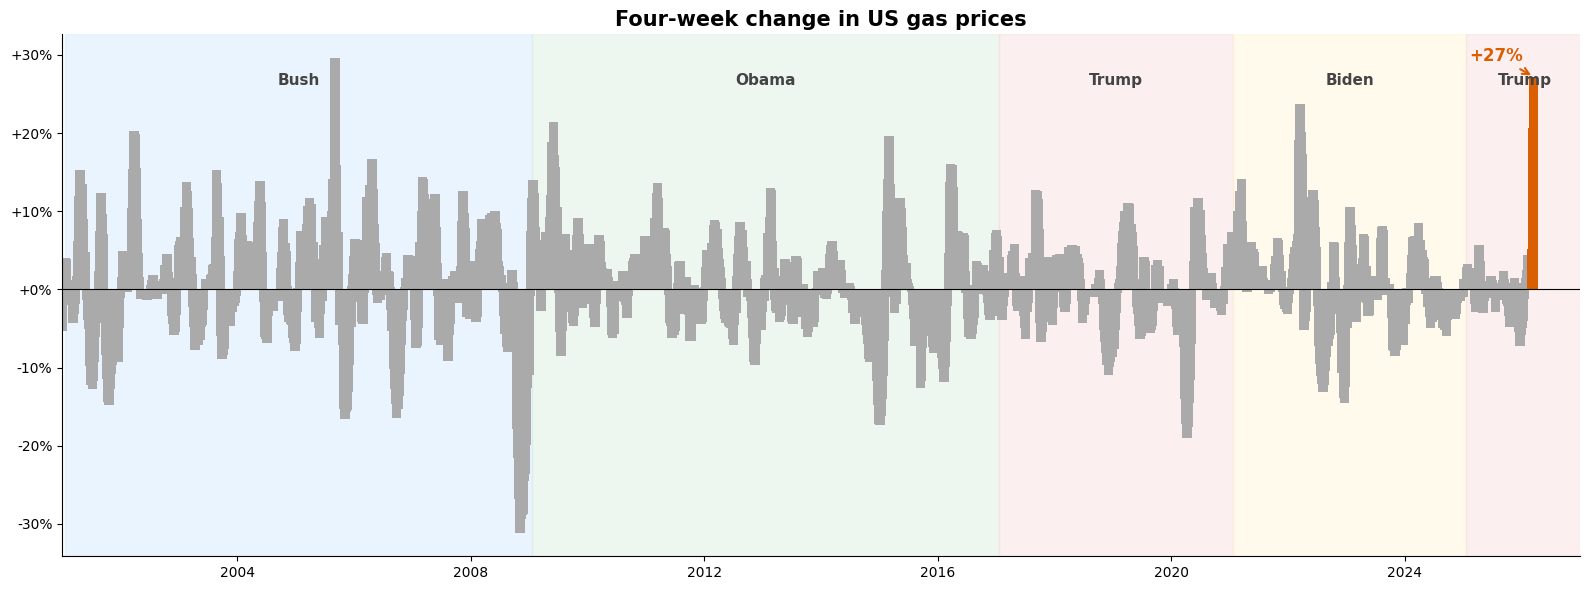

In [19]:
fig, ax = plt.subplots(figsize=(16, 6))

# ── Calculate 4-week percentage change ──
gas['pct_change_4w'] = gas['gas_price'].pct_change(periods=4) * 100

# ── Filter to 2001 onward ──
gas_plot = gas[gas['date'] >= '2001-01-01'].copy()

# ── Presidential term shading (draw first so bars sit on top) ──
presidents = [
    ('2001-01-20', '2009-01-20', 'Bush', '#cce5ff'),
    ('2009-01-20', '2017-01-20', 'Obama', '#d4edda'),
    ('2017-01-20', '2021-01-20', 'Trump', '#f8d7da'),
    ('2021-01-20', '2025-01-20', 'Biden', '#fff3cd'),
    ('2025-01-20', '2027-01-20', 'Trump', '#f8d7da'),
]
for start, end, name, color in presidents:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.4, color=color, zorder=0)

# ── Color bars: highlight Iran 2026 spike ──
colors = ['#d95f02' if d >= pd.Timestamp('2026-03-02') else '#aaaaaa' for d in gas_plot['date']]

# ── Plot bars ──
ax.bar(gas_plot['date'], gas_plot['pct_change_4w'], color=colors, width=60, zorder=2)

# ── Zero line ──
ax.axhline(0, color='black', linewidth=0.8, zorder=3)

# ── Annotate the Iran 2026 peak specifically ──
iran_plot = gas_plot[gas_plot['date'] >= '2026-03-02']
peak_idx = iran_plot['pct_change_4w'].idxmax()
peak_val = iran_plot['pct_change_4w'].max()
peak_date = iran_plot.loc[peak_idx, 'date']
ax.annotate(f'+{peak_val:.0f}%',
            xy=(peak_date, peak_val),
            xytext=(peak_date - pd.Timedelta(days=400), peak_val + 2),
            fontsize=12, fontweight='bold', color='#d95f02',
            arrowprops=dict(arrowstyle='->', color='#d95f02', lw=1.5))

# ── President labels at the top ──
for start, end, name, color in presidents:
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, ax.get_ylim()[1] * 0.85, name,
            fontsize=11, color='#444444', ha='center', va='top', fontweight='bold')

# ── Formatting ──
ax.set_title('Four-week change in US gas prices', fontsize=15, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
ax.set_xlim(pd.Timestamp('2001-01-01'), pd.Timestamp('2026-12-31'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/us_gas_4week_change.png', dpi=150)
plt.show()

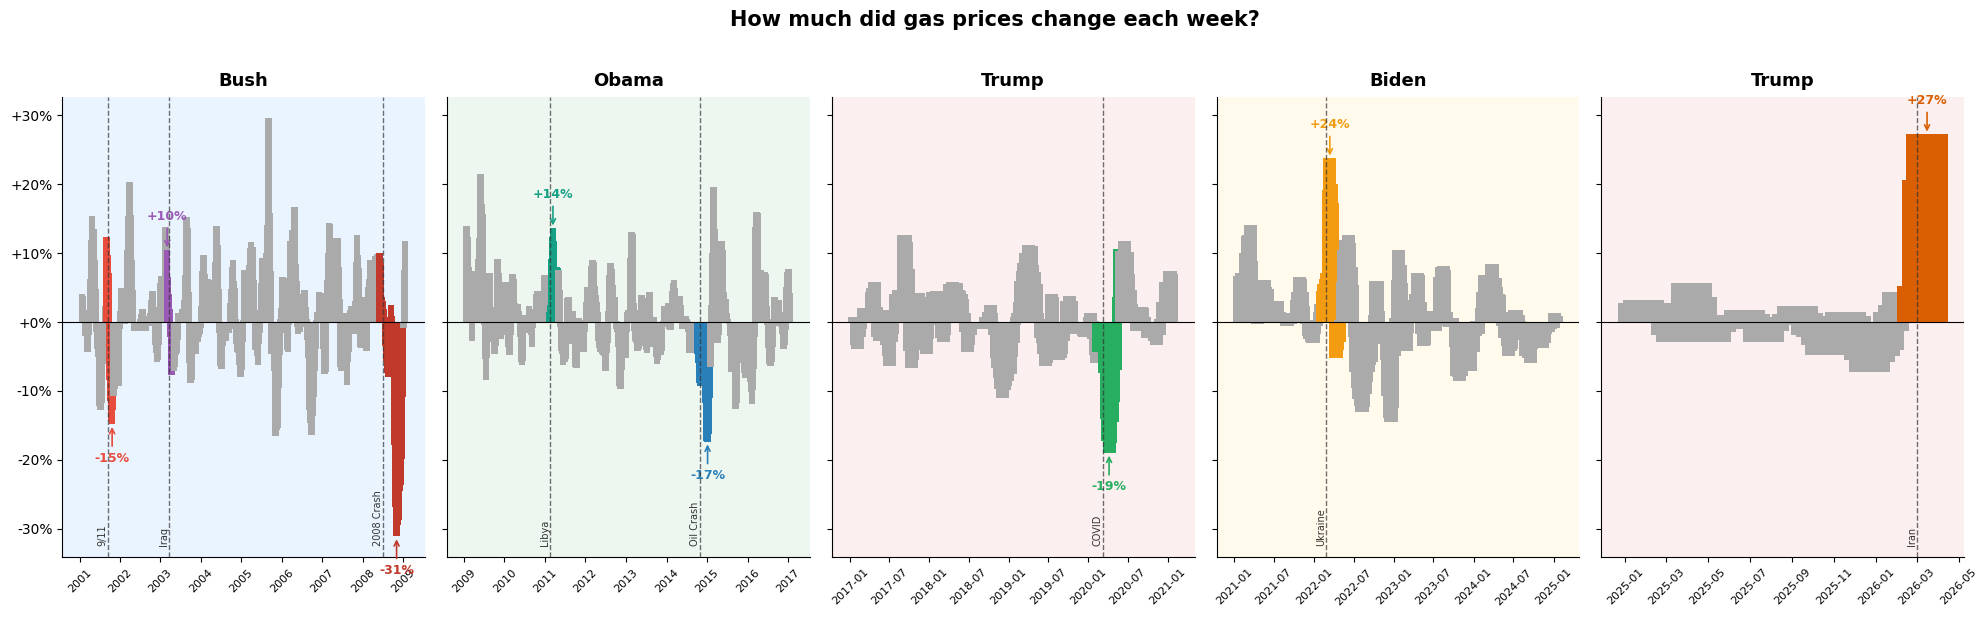

In [25]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

presidents = [
    ('2001-01-20', '2009-01-20', 'Bush', '#cce5ff', [
        ('2001-09-11', '9/11'),
        ('2003-03-20', 'Iraq'),
        ('2008-07-03', '2008 Crash'),
    ], [
        ('2001-09-01', '2001-11-01', '#e74c3c'),
        ('2003-03-01', '2003-05-01', '#9b59b6'),
        ('2008-06-01', '2008-12-31', '#c0392b'),
    ]),
    ('2009-01-20', '2017-01-20', 'Obama', '#d4edda', [
        ('2011-02-17', 'Libya'),
        ('2014-11-01', 'Oil Crash'),
    ], [
        ('2011-02-01', '2011-04-30', '#16a085'),
        ('2014-10-01', '2015-02-01', '#2980b9'),
    ]),
    ('2017-01-20', '2021-01-20', 'Trump', '#f8d7da', [
        ('2020-03-09', 'COVID'),
    ], [
        ('2020-02-15', '2020-06-01', '#27ae60'),
    ]),
    ('2021-01-20', '2025-01-20', 'Biden', '#fff3cd', [
        ('2022-02-24', 'Ukraine'),
    ], [
        ('2022-02-01', '2022-05-01', '#f39c12'),
    ]),
    ('2025-01-20', '2027-01-20', 'Trump', '#f8d7da', [
        ('2026-03-02', 'Iran'),
    ], [
        ('2026-03-02', '2027-01-20', '#d95f02'),
    ]),
]

for ax, (start, end, name, color, events, highlights) in zip(axes, presidents):
    mask = (gas_plot['date'] >= pd.Timestamp(start)) & (gas_plot['date'] < pd.Timestamp(end))
    term = gas_plot[mask].copy()

    def get_bar_color(date):
        for h_start, h_end, h_color in highlights:
            if pd.Timestamp(h_start) <= date < pd.Timestamp(h_end):
                return h_color
        return '#aaaaaa'

    bar_colors = [get_bar_color(d) for d in term['date']]
    ax.bar(term['date'], term['pct_change_4w'], color=bar_colors, width=60, zorder=2)
    ax.axhline(0, color='black', linewidth=0.8, zorder=3)
    ax.set_facecolor(color)
    ax.patch.set_alpha(0.4)
    ax.set_title(name, fontsize=13, fontweight='bold', pad=8)

    # Event lines only — no labels on the lines
    for date, label in events:
        ax.axvline(pd.Timestamp(date), color='#333333', linewidth=1, linestyle='--', alpha=0.7, zorder=4)

    # Annotate the peak of each highlighted window only
    for h_start, h_end, h_color in highlights:
        h_mask = (term['date'] >= pd.Timestamp(h_start)) & (term['date'] < pd.Timestamp(h_end))
        h_term = term[h_mask]
        if h_term.empty:
            continue

        # Find peak (positive or negative — whichever is more extreme)
        peak_idx = h_term['pct_change_4w'].idxmax()
        drop_idx = h_term['pct_change_4w'].idxmin()
        peak_val = h_term['pct_change_4w'].max()
        drop_val = h_term['pct_change_4w'].min()

        if abs(peak_val) >= abs(drop_val):
            val = peak_val
            date = h_term.loc[peak_idx, 'date']
            offset = val + 4
            va = 'bottom'
        else:
            val = drop_val
            date = h_term.loc[drop_idx, 'date']
            offset = val - 4
            va = 'top'

        ax.annotate(f'{val:+.0f}%',
                    xy=(date, val),
                    xytext=(date, offset),
                    fontsize=9, fontweight='bold', color=h_color, ha='center', va=va,
                    arrowprops=dict(arrowstyle='->', color=h_color, lw=1.2))

    # Event name labels at the bottom of each panel
    for date, label in events:
        ax.text(pd.Timestamp(date), ax.get_ylim()[0] * 0.95, label,
                fontsize=7, color='#333333', rotation=90, ha='right', va='bottom')

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

fig.suptitle('How much did gas prices change each week?', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/us_gas_by_president.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary Statistics by Presidential Term

Average, peak, and lowest gas price for each presidential term, plus the 
biggest single week percentage spike and drop. All prices are in nominal dollars.

In [26]:
# Define presidential terms
terms = [
    ('Bush',    '2001-01-20', '2009-01-20'),
    ('Obama',   '2009-01-20', '2017-01-20'),
    ('Trump I', '2017-01-20', '2021-01-20'),
    ('Biden',   '2021-01-20', '2025-01-20'),
    ('Trump II','2025-01-20', '2027-01-20'),
]

rows = []
for name, start, end in terms:
    mask = (gas['date'] >= pd.Timestamp(start)) & (gas['date'] < pd.Timestamp(end))
    term = gas[mask]
    rows.append({
        'President': name,
        'Avg Price ($/gal)': term['gas_price'].mean().round(3),
        'Peak Price ($/gal)': term['gas_price'].max().round(3),
        'Lowest Price ($/gal)': term['gas_price'].min().round(3),
        'Biggest Weekly Spike (%)': term['pct_change_4w'].max().round(1),
        'Biggest Weekly Drop (%)': term['pct_change_4w'].min().round(1),
    })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

President  Avg Price ($/gal)  Peak Price ($/gal)  Lowest Price ($/gal)  Biggest Weekly Spike (%)  Biggest Weekly Drop (%)
     Bush              2.135               4.114                 1.059                      29.6                    -31.1
    Obama              2.970               3.965                 1.724                      21.5                    -17.4
  Trump I              2.476               2.962                 1.773                      12.7                    -19.0
    Biden              3.457               5.006                 2.392                      23.7                    -14.5
 Trump II              3.083               3.720                 2.779                      27.2                     -7.2


## What the Numbers Show

A few things stand out from the summary table:

- **Highest average price:** Biden at $3.46/gallon, nearly $1 more per gallon 
  than the Bush average. In nominal terms Biden was the most expensive era 
  at the pump by a clear margin
- **Highest single price:** Biden again at $5.01/gallon, reached during the 
  post-Ukraine invasion spike in 2022
- **Cheapest era:** Bush, with an average of $2.14 and a low of $1.06. 
  Inflation adjustment would close that gap significantly
- **Biggest weekly spike:** Bush at +29.6%, driven by Hurricane Katrina 
  wiping out Gulf Coast refinery capacity in 2005
- **Biggest weekly drop:** Also Bush at -31.1%, during the 2008 financial 
  crisis as demand collapsed overnight
- **Trump II:** Still early, but already has the second biggest weekly spike 
  in the dataset at +27.2% driven by the Iran 2026 conflict

In [27]:
summary.to_csv('../outputs/gas_summary_by_president.csv', index=False)
print("Saved!")

Saved!


## Gas Price Changes by Presidential Term — Inflation-Adjusted

The same per-president panel view using inflation-adjusted prices in 
February 2026 dollars. Every term is now directly comparable in real 
purchasing power terms rather than nominal dollars.

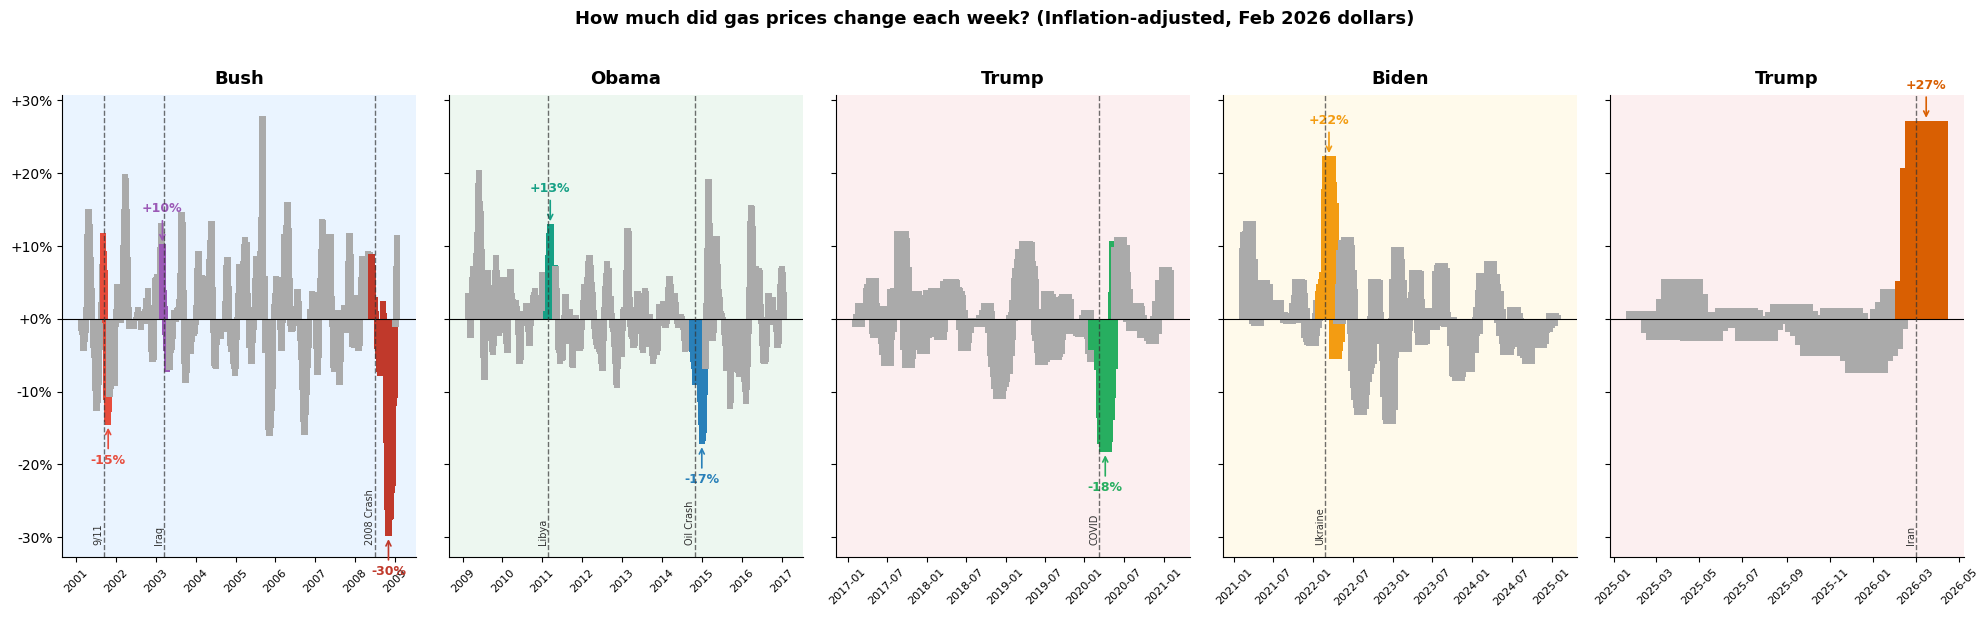

In [29]:
fig, axes = plt.subplots(1, 5, figsize=(20, 6), sharey=True)

for ax, (start, end, name, color, events, highlights) in zip(axes, presidents):
    mask = (gas_plot['date'] >= pd.Timestamp(start)) & (gas_plot['date'] < pd.Timestamp(end))
    term = gas_plot[mask].copy()

    # Use inflation-adjusted price instead of nominal
    def get_bar_color(date):
        for h_start, h_end, h_color in highlights:
            if pd.Timestamp(h_start) <= date < pd.Timestamp(h_end):
                return h_color
        return '#aaaaaa'

    bar_colors = [get_bar_color(d) for d in term['date']]

    # Calculate 4 week pct change on adjusted price
    term['pct_change_4w_adj'] = term['gas_price_adjusted'].pct_change(periods=4) * 100

    ax.bar(term['date'], term['pct_change_4w_adj'], color=bar_colors, width=60, zorder=2)
    ax.axhline(0, color='black', linewidth=0.8, zorder=3)
    ax.set_facecolor(color)
    ax.patch.set_alpha(0.4)
    ax.set_title(name, fontsize=13, fontweight='bold', pad=8)

    for date, label in events:
        ax.axvline(pd.Timestamp(date), color='#333333', linewidth=1, linestyle='--', alpha=0.7, zorder=4)

    for h_start, h_end, h_color in highlights:
        h_mask = (term['date'] >= pd.Timestamp(h_start)) & (term['date'] < pd.Timestamp(h_end))
        h_term = term[h_mask]
        if h_term.empty:
            continue

        peak_idx = h_term['pct_change_4w_adj'].idxmax()
        drop_idx = h_term['pct_change_4w_adj'].idxmin()
        peak_val = h_term['pct_change_4w_adj'].max()
        drop_val = h_term['pct_change_4w_adj'].min()

        if abs(peak_val) >= abs(drop_val):
            val = peak_val
            date = h_term.loc[peak_idx, 'date']
            offset = val + 4
            va = 'bottom'
        else:
            val = drop_val
            date = h_term.loc[drop_idx, 'date']
            offset = val - 4
            va = 'top'

        ax.annotate(f'{val:+.0f}%',
                    xy=(date, val),
                    xytext=(date, offset),
                    fontsize=9, fontweight='bold', color=h_color, ha='center', va=va,
                    arrowprops=dict(arrowstyle='->', color=h_color, lw=1.2))

    for date, label in events:
        ax.text(pd.Timestamp(date), ax.get_ylim()[0] * 0.95, label,
                fontsize=7, color='#333333', rotation=90, ha='right', va='bottom')

    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:+.0f}%'))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=45, labelsize=8)

fig.suptitle('How much did gas prices change each week? (Inflation-adjusted, Feb 2026 dollars)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/us_gas_by_president_adjusted.png', dpi=150, bbox_inches='tight')
plt.show()

## Why the Two Charts Look Nearly Identical

The percentage changes in the inflation-adjusted chart look almost the same 
as the nominal version. That is expected. Inflation moves slowly, fractions 
of a percent per month, while gas prices can swing 10 to 30% in a matter of weeks.

Adjusting for inflation matters most when comparing price levels across 
decades, not week-to-week change rates. For that comparison, see the 
side-by-side chart above — that is where inflation adjustment tells the 
most interesting story.

## Aligning Weekly Gas and Brent Data

Gas prices are reported weekly on Mondays. Brent crude is daily, so we 
resample it to weekly averages. The problem is the two weekly series don't 
fall on the same day — gas lands on Mondays, Brent weekly averages land on 
Sundays — so a direct date merge returns zero matches.

The fix is to merge on ISO year and week number instead of exact date. 
Any gas price reading and any Brent weekly average that fall in the same 
calendar week get matched together regardless of which day they land on.

In [32]:
# Add year and week columns to both
gas_w = gas[['date', 'gas_price', 'pct_change_4w']].copy()
gas_w['year'] = gas_w['date'].dt.isocalendar().year
gas_w['week'] = gas_w['date'].dt.isocalendar().week

brent_weekly['year'] = brent_weekly['date'].dt.isocalendar().year
brent_weekly['week'] = brent_weekly['date'].dt.isocalendar().week

# Merge on year and week
combined = pd.merge(gas_w, brent_weekly[['year', 'week', 'brent', 'brent_pct']],
                    on=['year', 'week'], how='inner')

combined = combined.dropna()
print(combined.shape)
print(combined.head())

(1719, 7)
        date  gas_price  pct_change_4w  year  week   brent  brent_pct
1 1993-04-12      1.079       1.984877  1993    15  18.638  -0.371509
2 1993-04-19      1.079       2.178030  1993    16  18.560  -0.418500
3 1993-04-26      1.086       2.743614  1993    17  18.668   0.581897
4 1993-05-03      1.086       1.685393  1993    18  18.942   1.467752
5 1993-05-10      1.097       1.668211  1993    19  18.762  -0.950269


## How Tightly Do Gas and Brent Move Together?

We already know from notebook 04 that the annual correlation between oil 
prices and US inflation is 0.63. But how tightly do weekly gas prices 
track weekly Brent crude movements?

This cell calculates the correlation between week-to-week percentage 
changes in Brent and week-to-week percentage changes in gas prices. 
A high correlation means crude price shocks pass through to the pump 
quickly. A lower correlation suggests other factors — refinery capacity, 
taxes, distribution costs — absorb some of the shock.

Both series use 1-week percentage changes so the time windows match.

In [34]:
# Use 1-week change for both to match time windows
gas_w['gas_pct_1w'] = gas_w['gas_price'].pct_change(periods=1) * 100

combined = pd.merge(gas_w, brent_weekly[['year', 'week', 'brent', 'brent_pct']],
                    on=['year', 'week'], how='inner')
combined = combined.dropna()

corr = combined['gas_pct_1w'].corr(combined['brent_pct'])
print(f"Weekly correlation (1-week changes): {corr:.3f}")

Weekly correlation (1-week changes): 0.214


## Testing for a Lag Effect

A weekly correlation of 0.214 is surprisingly low given how closely gas 
and Brent track over months and years. The likely explanation is a lag. 
Crude price moves don't show up at the pump instantly. Refineries buy 
crude, process it, ship it to distributors, and then it hits the pump. 
That pipeline takes time.

This cell tests correlations at 0 to 6 week lags to find exactly how 
long that process takes.

In [35]:
# Test correlations at different lags
for lag in range(0, 7):
    combined[f'brent_lag{lag}'] = combined['brent_pct'].shift(lag)
    corr = combined['gas_pct_1w'].corr(combined[f'brent_lag{lag}'])
    print(f"Lag {lag} weeks: r = {corr:.3f}")

Lag 0 weeks: r = 0.214
Lag 1 weeks: r = 0.544
Lag 2 weeks: r = 0.374
Lag 3 weeks: r = 0.222
Lag 4 weeks: r = 0.205
Lag 5 weeks: r = 0.122
Lag 6 weeks: r = 0.095


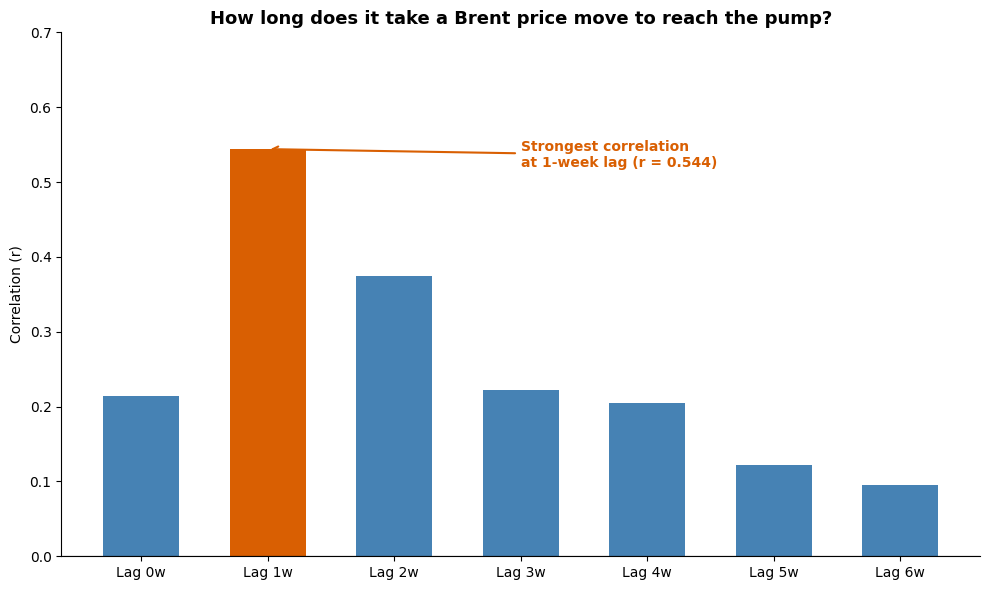

In [36]:
lags = range(0, 7)
correlations = [combined['gas_pct_1w'].corr(combined[f'brent_lag{lag}']) for lag in lags]

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#d95f02' if c == max(correlations) else 'steelblue' for c in correlations]
ax.bar([f'Lag {l}w' for l in lags], correlations, color=colors, width=0.6)
ax.axhline(0, color='black', linewidth=0.8)

# Annotate peak
ax.annotate('Strongest correlation\nat 1-week lag (r = 0.544)',
            xy=('Lag 1w', 0.544),
            xytext=('Lag 3w', 0.52),
            fontsize=10, color='#d95f02', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#d95f02', lw=1.5))

ax.set_title('How long does it take a Brent price move to reach the pump?',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Correlation (r)')
ax.set_ylim(0, 0.7)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/gas_brent_lag_correlation.png', dpi=150)
plt.show()

## The Pipeline Takes One Week

The correlation jumps from 0.214 at lag 0 to 0.544 at lag 1, then drops 
off sharply after that. The answer is clear: Brent price changes take 
approximately one week to show up at the pump.

This has real implications for consumers. When oil prices spike, expect 
to feel it at the gas station the following week, not the same day.

In [37]:
gas_final = gas[['date', 'gas_price', 'gas_price_adjusted', 'pct_change_4w']].copy()
gas_final['gas_pct_1w'] = gas['gas_price'].pct_change(periods=1) * 100
gas_final.to_csv('../outputs/us_gas_prices.csv', index=False)
print(f"Saved {len(gas_final)} rows")
print(gas_final.tail())

Saved 1733 rows
           date  gas_price  gas_price_adjusted  pct_change_4w  gas_pct_1w
1728 2026-02-16      2.924               2.924       4.205274    0.758098
1729 2026-02-23      2.937               2.937       2.944269    0.444596
1730 2026-03-02      3.015               3.015       5.162190    2.655771
1731 2026-03-09      3.502               3.502      20.675396   16.152570
1732 2026-03-16      3.720               3.720      27.222982    6.225014
